In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alicia2uu/neurobiosense-dataset/NeuroBioSense Dataset/NeuroBioSense/Biosignal Files/Pre-Processed/32-Hertz.csv
/kaggle/input/datasets/alicia2uu/neurobiosense-dataset/NeuroBioSense Dataset/NeuroBioSense/Biosignal Files/Pre-Processed/64-Hertz.csv
/kaggle/input/datasets/alicia2uu/neurobiosense-dataset/NeuroBioSense Dataset/NeuroBioSense/Biosignal Files/Pre-Processed/4-Hertz.csv
/kaggle/input/datasets/alicia2uu/neurobiosense-dataset/NeuroBioSense Dataset/NeuroBioSense/Biosignal Files/Raw/ACC(32-Hertz)/ACC.csv
/kaggle/input/datasets/alicia2uu/neurobiosense-dataset/NeuroBioSense Dataset/NeuroBioSense/Biosignal Files/Raw/BVP(64-Hertz)/BVP.csv
/kaggle/input/datasets/alicia2uu/neurobiosense-dataset/NeuroBioSense Dataset/NeuroBioSense/Biosignal Files/Raw/TEMP(4-Hertz)/TEMP.csv
/kaggle/input/datasets/alicia2uu/neurobiosense-dataset/NeuroBioSense Dataset/NeuroBioSense/Biosignal Files/Raw/EDA(4-Hertz)/EDA.csv
/kaggle/input/datasets/alicia2uu/neurobiosense-dataset/NeuroBioSens

In [2]:
!pip install -q lightgbm xgboost --upgrade

In [3]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
 
import xgboost as xgb
import lightgbm as lgb
 
warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [11]:
FILE_PATH = "/kaggle/input/datasets/alicia2uu/neurobiosense-dataset/NeuroBioSense Dataset/NeuroBioSense/Participant Data/Participant_demographic_questionnaries.xlsx"
 
df = pd.read_excel(FILE_PATH, sheet_name="Sheet1")
df.columns = df.columns.str.strip()
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
 
# Forward-fill participant-level info
for col in ["RECORD ID", "SUBJECT ID", "GENDER", "AGE"]:
    if col in df.columns:
        df[col] = df[col].ffill()
 
# Normalise label  (Yes/yes → 1,  No/no → 0)
df["label"] = (
    df["INTERESTED IN"]
    .astype(str).str.strip().str.lower()
    .map({"yes": 1, "no": 0})
)
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)
print("\nLabel balance:\n", df["label"].value_counts())
 

Columns: ['SIGNALID', 'SUBID', 'GENDER', 'AGE', 'ADDNO', 'TIME', 'P/N (1-5)', 'EMOTIONS (%)', 'INTERESTED IN']
Shape: (670, 9)

Label balance:
 label
1    455
0    215
Name: count, dtype: int64


In [10]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if "demographic" in file.lower() or "questionnaire" in file.lower() or "questionnarie" in file.lower():
            print(os.path.join(root, file))

/kaggle/input/datasets/alicia2uu/neurobiosense-dataset/NeuroBioSense Dataset/NeuroBioSense/Participant Data/Participant_demographic_questionnaries.xlsx


In [12]:
EMOTION_CODES = ["J", "SU", "F", "D", "SA", "A"]
 
def parse_emotions(s):
    result = {c: 0.0 for c in EMOTION_CODES}
    if not isinstance(s, str) or s.strip() in ("-", ""):
        return result
    # Match  CODE%INT  or  CODE-INT  (both separators seen in data)
    tokens = re.findall(r"([A-Z]+)[%\-](\d*\.?\d+)", s)
    for code, pct in tokens:
        if code in result and pct:
            result[code] = min(float(pct) / 100.0, 1.0)
    return result
 
emo_parsed = df["EMOTIONS (%)"].apply(parse_emotions)
for code in EMOTION_CODES:
    df[f"emo_{code}"] = emo_parsed.apply(lambda d: d[code])
 
print("\nSample emotion columns:")
print(df[[f"emo_{c}" for c in EMOTION_CODES]].head())


Sample emotion columns:
   emo_J  emo_SU  emo_F  emo_D  emo_SA  emo_A
0    0.4     0.3    0.0    0.0     0.0    0.0
1    0.6     0.0    0.0    0.0     0.0    0.0
2    0.0     0.7    0.0    0.0     0.0    0.0
3    0.5     0.5    0.0    0.0     0.0    0.0
4    0.0     0.0    0.7    0.7     0.0    0.0


In [15]:
# ============================================================
# CELL 5 — Feature engineering (corrected column names)
# ============================================================
emo_cols = [f"emo_{c}" for c in EMOTION_CODES]

# --- Basic demographic features ---
df["gender_bin"] = (
    df["GENDER"].astype(str).str.strip().str.lower() == "male"
).astype(float)

df["age"] = pd.to_numeric(df["AGE"], errors="coerce")
df["age"] = df["age"].fillna(df["age"].median())

# Age buckets (teen <18, young 18-30, adult 30-50, senior 50+)
df["age_group"] = pd.cut(
    df["age"], bins=[0, 18, 30, 50, 120], labels=[0, 1, 2, 3]
).astype(float).fillna(1.0)

# Time column
df["time_val"] = pd.to_numeric(df["TIME"], errors="coerce").fillna(0)
df["time_log"] = np.log1p(np.abs(df["time_val"]))

# Ad number (1–15)
df["ad_code"] = pd.to_numeric(df["ADDNO"], errors="coerce").fillna(0).astype(float)

# P/N rating (1–5 scale, positive/negative sentiment rating)
df["pn_rating"] = pd.to_numeric(df["P/N (1-5)"], errors="coerce").fillna(3.0)

# --- Emotion aggregate features ---
df["emo_max"]     = df[emo_cols].max(axis=1)
df["emo_mean"]    = df[emo_cols].mean(axis=1)
df["emo_sum"]     = df[emo_cols].sum(axis=1)
df["emo_count"]   = (df[emo_cols] > 0).sum(axis=1).astype(float)
df["emo_std"]     = df[emo_cols].std(axis=1).fillna(0)
df["emo_entropy"] = df[emo_cols].apply(
    lambda row: -np.sum([p * np.log(p + 1e-9) for p in row if p > 0]), axis=1
)

# Dominant emotion
df["dom_emo_idx"]       = df[emo_cols].values.argmax(axis=1).astype(float)
df["dom_emo_intensity"] = df["emo_max"]

# One-hot dominant emotion
for i, code in enumerate(EMOTION_CODES):
    df[f"dom_{code}"] = (df["dom_emo_idx"] == i).astype(float)

# Positive vs negative emotion
POS_EMOTIONS = ["emo_J", "emo_SU"]
NEG_EMOTIONS = ["emo_F", "emo_D", "emo_SA", "emo_A"]
df["pos_emo_sum"]   = df[POS_EMOTIONS].sum(axis=1)
df["neg_emo_sum"]   = df[NEG_EMOTIONS].sum(axis=1)
df["pos_neg_ratio"] = df["pos_emo_sum"] / (df["neg_emo_sum"] + 1e-9)

# Interaction features
df["joy_x_surprise"]  = df["emo_J"] * df["emo_SU"]
df["strong_positive"] = ((df["emo_J"] > 0.5) | (df["emo_SU"] > 0.5)).astype(float)
df["neg_dominant"]    = (df["neg_emo_sum"] > df["pos_emo_sum"]).astype(float)

# P/N × emotion interactions
df["pn_x_joy"]      = df["pn_rating"] * df["emo_J"]
df["pn_x_surprise"] = df["pn_rating"] * df["emo_SU"]

FEATURE_COLS = (
    ["gender_bin", "age", "age_group", "time_log", "ad_code", "pn_rating"]
    + emo_cols
    + [f"dom_{c}" for c in EMOTION_CODES]
    + ["emo_max", "emo_mean", "emo_sum", "emo_count", "emo_std", "emo_entropy"]
    + ["dom_emo_idx", "dom_emo_intensity"]
    + ["pos_emo_sum", "neg_emo_sum", "pos_neg_ratio",
       "joy_x_surprise", "strong_positive", "neg_dominant",
       "pn_x_joy", "pn_x_surprise"]
)

print(f"Total features: {len(FEATURE_COLS)}")

X = df[FEATURE_COLS].values.astype(np.float32)
y = df["label"].values.astype(np.int64)
print(f"X shape: {X.shape}  |  Class balance: {np.bincount(y)}")


Total features: 34
X shape: (670, 34)  |  Class balance: [215 455]


In [16]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test_sc  = scaler.transform(X_test_raw).astype(np.float32)
 
print(f"Train: {X_train_sc.shape}  Test: {X_test_sc.shape}")
print(f"Train label balance: {np.bincount(y_train)}")
print(f"Test  label balance: {np.bincount(y_test)}")

Train: (536, 34)  Test: (134, 34)
Train label balance: [172 364]
Test  label balance: [43 91]


In [17]:
cw_arr = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
scale_pos = cw_arr[1] / cw_arr[0]   # for XGBoost
 
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
)
xgb_model.fit(
    X_train_raw, y_train,
    eval_set=[(X_test_raw, y_test)],
    verbose=False
)
xgb_preds = xgb_model.predict(X_test_raw)
xgb_probs = xgb_model.predict_proba(X_test_raw)[:, 1]
 
print("=" * 50)
print("XGBoost Results")
print("=" * 50)
print(classification_report(y_test, xgb_preds,
      target_names=["Not Interested", "Interested"]))
print(f"Accuracy : {accuracy_score(y_test, xgb_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, xgb_probs):.4f}")

XGBoost Results
                precision    recall  f1-score   support

Not Interested       0.65      0.72      0.68        43
    Interested       0.86      0.81      0.84        91

      accuracy                           0.78       134
     macro avg       0.75      0.77      0.76       134
  weighted avg       0.79      0.78      0.79       134

Accuracy : 0.7836
ROC-AUC  : 0.8520


In [18]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgb_model.fit(
    X_train_raw, y_train,
    eval_set=[(X_test_raw, y_test)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
)
lgb_preds = lgb_model.predict(X_test_raw)
lgb_probs = lgb_model.predict_proba(X_test_raw)[:, 1]
 
print("=" * 50)
print("LightGBM Results")
print("=" * 50)
print(classification_report(y_test, lgb_preds,
      target_names=["Not Interested", "Interested"]))
print(f"Accuracy : {accuracy_score(y_test, lgb_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, lgb_probs):.4f}")
 

LightGBM Results
                precision    recall  f1-score   support

Not Interested       0.67      0.79      0.72        43
    Interested       0.89      0.81      0.85        91

      accuracy                           0.81       134
     macro avg       0.78      0.80      0.79       134
  weighted avg       0.82      0.81      0.81       134

Accuracy : 0.8060
ROC-AUC  : 0.8594


In [20]:
class TabTransformer(nn.Module):
    """
    TabTransformer for binary tabular classification.
 
    Architecture:
      1. Linear projection → embeds each of the N features to d_model dims
      2. Learnable positional encoding added to embeddings
      3. Transformer encoder (multi-head self-attention) — learns
         interactions between features (e.g. Joy × Sadness × Age)
      4. Global average pool over feature axis
      5. MLP classification head
 
    Why better than plain CNN for this data?
      - Self-attention captures GLOBAL feature interactions (any feature
        pair), not just local neighbours like Conv1D does.
      - Particularly strong at emotion×demographic interactions.
 
    Fusion hook:
      Call extract_features(x) to get 128-d embedding for
      MobileNet fusion later.
    """
    def __init__(
        self,
        num_features: int,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 3,
        dim_feedforward: int = 256,
        dropout: float = 0.3,
    ):
        super().__init__()
 
        # Project each scalar feature → d_model vector
        self.input_proj = nn.Linear(1, d_model)
 
        # Learnable positional encoding (one per feature)
        self.pos_enc = nn.Parameter(torch.randn(num_features, d_model) * 0.02)
 
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,          # (batch, seq, d_model)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
 
        # MLP head
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(d_model, 128)
        self.fc2     = nn.Linear(128, 2)
 
    def _backbone(self, x):
        # x: (batch, num_features)
        x = x.unsqueeze(-1)                        # (batch, F, 1)
        x = self.input_proj(x)                     # (batch, F, d_model)
        x = x + self.pos_enc.unsqueeze(0)          # add positional encoding
        x = self.transformer(x)                    # (batch, F, d_model)
        x = self.norm(x)
        x = x.mean(dim=1)                          # global avg pool → (batch, d_model)
        return x
 
    def extract_features(self, x):
        """128-d embedding for late fusion with video branch."""
        h = self._backbone(x)
        h = self.dropout(h)
        return F.relu(self.fc1(h))                 # (batch, 128)
 
    def forward(self, x):
        h = self.extract_features(x)
        h = self.dropout(h)
        return self.fc2(h)

In [21]:
def make_loader(X, y, batch_size=32, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      drop_last=False)
 
 
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct    += (model(xb).argmax(1) == yb).sum().item()
        n          += len(yb)
    return total_loss / n, correct / n
 
 
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_probs, all_labels  = [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits  = model(xb)
        loss    = criterion(logits, yb)
        probs   = F.softmax(logits, dim=1)[:, 1]
        total_loss += loss.item() * len(yb)
        correct    += (logits.argmax(1) == yb).sum().item()
        n          += len(yb)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / n, correct / n, auc, all_probs, all_labels

In [22]:
EPOCHS     = 150
BATCH_SIZE = 32
LR         = 1e-3
 
num_features = X_train_sc.shape[1]
model = TabTransformer(num_features=num_features).to(DEVICE)
 
# Weighted loss for class imbalance
cw_vals = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(cw_vals, dtype=torch.float32).to(DEVICE)
)
 
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
 
train_loader = make_loader(X_train_sc, y_train, BATCH_SIZE)
test_loader  = make_loader(X_test_sc,  y_test,  BATCH_SIZE, shuffle=False)
 
history = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[], val_auc=[])
best_auc, best_state = 0.0, None
 
print("Training TabTransformer ...")
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc, va_auc, _, _ = evaluate(model, test_loader, criterion)
    scheduler.step()
 
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["val_auc"].append(va_auc)
 
    if va_auc > best_auc:
        best_auc   = va_auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
 
    if epoch % 25 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Loss {tr_loss:.4f}/{va_loss:.4f} | "
              f"Acc {tr_acc:.3f}/{va_acc:.3f} | "
              f"AUC {va_auc:.4f}")
 
print(f"\nBest Val AUC: {best_auc:.4f}")

Training TabTransformer ...
Epoch  25/150 | Loss 0.5260/0.4973 | Acc 0.761/0.784 | AUC 0.8198
Epoch  50/150 | Loss 0.4766/0.4722 | Acc 0.780/0.813 | AUC 0.8702
Epoch  75/150 | Loss 0.4683/0.4893 | Acc 0.793/0.791 | AUC 0.8600
Epoch 100/150 | Loss 0.4560/0.6235 | Acc 0.787/0.769 | AUC 0.8173
Epoch 125/150 | Loss 0.4228/0.6133 | Acc 0.802/0.791 | AUC 0.8175
Epoch 150/150 | Loss 0.4215/0.6559 | Acc 0.804/0.769 | AUC 0.8032

Best Val AUC: 0.8858


In [23]:
model.load_state_dict(best_state)
_, tab_acc, tab_auc, tab_probs, tab_labels = evaluate(model, test_loader, criterion)
 
tab_preds = [1 if p > 0.5 else 0 for p in tab_probs]
 
print("=" * 50)
print("TabTransformer Results  (best checkpoint)")
print("=" * 50)
print(classification_report(tab_labels, tab_preds,
      target_names=["Not Interested", "Interested"]))
print(f"Accuracy : {accuracy_score(tab_labels, tab_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(tab_labels, tab_probs):.4f}")

TabTransformer Results  (best checkpoint)
                precision    recall  f1-score   support

Not Interested       0.68      0.84      0.75        43
    Interested       0.91      0.81      0.86        91

      accuracy                           0.82       134
     macro avg       0.80      0.83      0.81       134
  weighted avg       0.84      0.82      0.83       134

Accuracy : 0.8209
ROC-AUC  : 0.8858


In [24]:
print("\n" + "=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
results = {
    "XGBoost"        : (accuracy_score(y_test, xgb_preds),
                        roc_auc_score(y_test, xgb_probs)),
    "LightGBM"       : (accuracy_score(y_test, lgb_preds),
                        roc_auc_score(y_test, lgb_probs)),
    "TabTransformer" : (accuracy_score(tab_labels, tab_preds),
                        roc_auc_score(tab_labels, tab_probs)),
}
for name, (acc, auc) in sorted(results.items(), key=lambda x: -x[1][1]):
    print(f"  {name:<20}  Acc={acc:.4f}   AUC={auc:.4f}")
 


MODEL COMPARISON SUMMARY
  TabTransformer        Acc=0.8209   AUC=0.8858
  LightGBM              Acc=0.8060   AUC=0.8594
  XGBoost               Acc=0.7836   AUC=0.8520


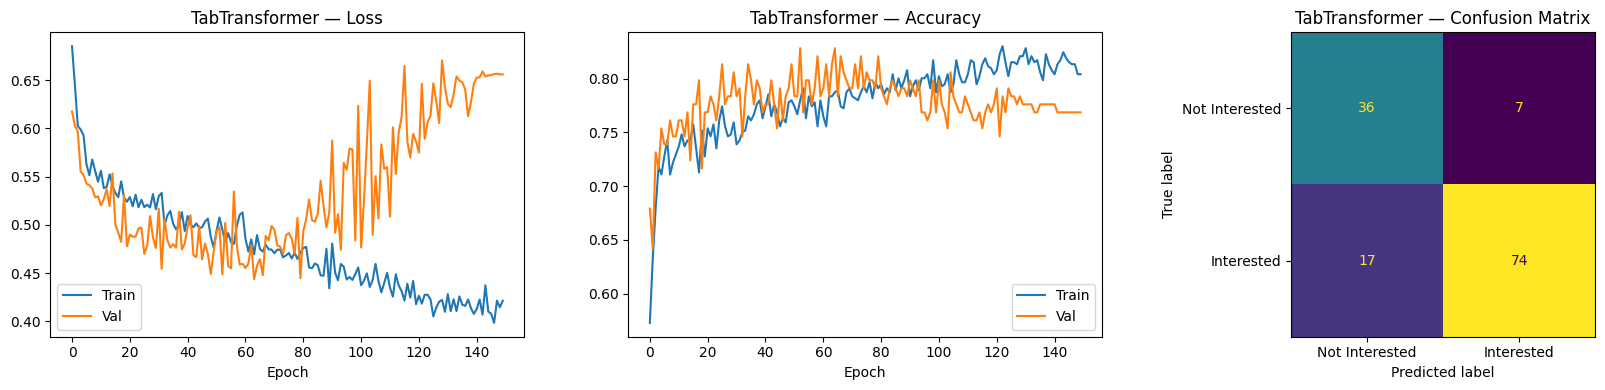

Plot saved.


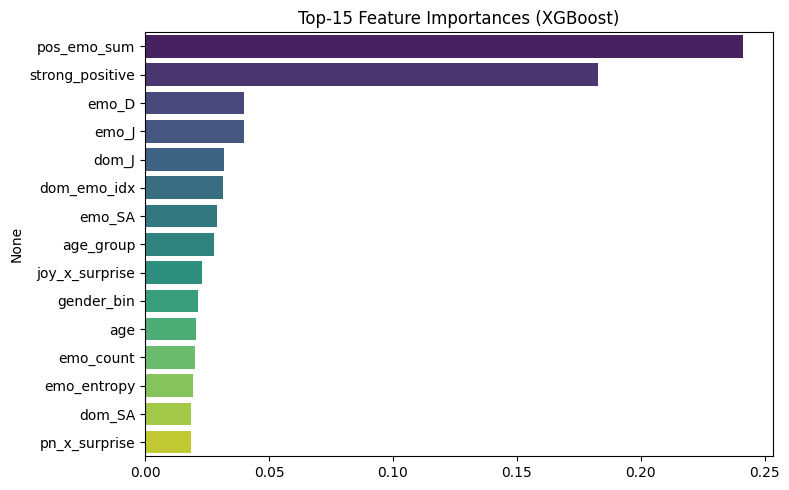

Top features:
 pos_emo_sum        0.241229
strong_positive    0.182954
emo_D              0.040124
emo_J              0.039970
dom_J              0.031709
dom_emo_idx        0.031533
emo_SA             0.028946
age_group          0.027965
joy_x_surprise     0.023051
gender_bin         0.021472
age                0.020541
emo_count          0.020144
emo_entropy        0.019369
dom_SA             0.018425
pn_x_surprise      0.018390
dtype: float32


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
 
# Loss
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("TabTransformer — Loss")
axes[0].set_xlabel("Epoch"); axes[0].legend()
 
# Accuracy
axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"],   label="Val")
axes[1].set_title("TabTransformer — Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].legend()
 
# Confusion matrix
cm = confusion_matrix(tab_labels, tab_preds)
ConfusionMatrixDisplay(cm, display_labels=["Not Interested", "Interested"]).plot(
    ax=axes[2], colorbar=False
)
axes[2].set_title("TabTransformer — Confusion Matrix")
 
plt.tight_layout()
plt.savefig("tabtransformer_results.png", dpi=120)
plt.show()
print("Plot saved.")
 
 
# ============================================================
# CELL 15 — Feature importance (XGBoost)
# ============================================================
feat_imp = pd.Series(
    xgb_model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=False).head(15)
 
plt.figure(figsize=(8, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")
plt.title("Top-15 Feature Importances (XGBoost)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120)
plt.show()
print("Top features:\n", feat_imp)

In [26]:
import joblib
 
# Save TabTransformer (for DL fusion pipeline)
torch.save(best_state,         "tabtransformer_weights.pt")
joblib.dump(scaler,            "demo_scaler.pkl")
joblib.dump(FEATURE_COLS,      "demo_feature_cols.pkl")
 
# Save best tree model (standalone use)
best_tree_name = max(results, key=lambda k: results[k][1])
print(f"\nBest overall model: {best_tree_name}")
if best_tree_name == "XGBoost":
    xgb_model.save_model("best_tree_model.json")
    print("Saved XGBoost → best_tree_model.json")
elif best_tree_name == "LightGBM":
    lgb_model.booster_.save_model("best_tree_model.txt")
    print("Saved LightGBM → best_tree_model.txt")
 
print("\nSaved artefacts:")
print("  tabtransformer_weights.pt  ← DL weights for fusion")
print("  demo_scaler.pkl            ← StandardScaler")
print("  demo_feature_cols.pkl      ← feature order")
print("  best_tree_model.*          ← best tree model standalone")


Best overall model: TabTransformer

Saved artefacts:
  tabtransformer_weights.pt  ← DL weights for fusion
  demo_scaler.pkl            ← StandardScaler
  demo_feature_cols.pkl      ← feature order
  best_tree_model.*          ← best tree model standalone
